# TASK_2 Predict Future Stock Prices (Short-Term)

In [1]:
pip install yfinance


  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
     ---------------------------------------- 0.0/949.2 kB ? eta -:--:--
     ------------------------------- ------ 786.4/949.2 kB 4.2 MB/s eta 0:00:01
     -------------------------------------- 949.2/949.2 kB 4.0 MB/s eta 0:00:00
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ------------------- -------------------- 0.8/1.6 MB 4.2 MB/s eta 0:00:01
   ---------------------------------------- 1.6/1.6 MB 3.9 MB/s eta 0:00:00
  Created wheel for multitasking: filename=multitasking-0.0.12-py3-none-any.whl size=15671 sha256=cc93bc0033efccf2

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


C:\Users\Hp\AppData\Local\Temp\ipykernel_14068\3392610833.py:16: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(stock_symbol, start='2020-01-01', end='2025-08-01')
[*********************100%***********************]  1 of 1 completed
C:\Users\Hp\anaconda3\envs\ML25\lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


🔍 Linear Regression:
MSE: 18.198789828825493
R2 Score: 0.9209428749184844

🌲 Random Forest Regressor:
MSE: 548.5322822455422
R2 Score: -1.3828719193211203


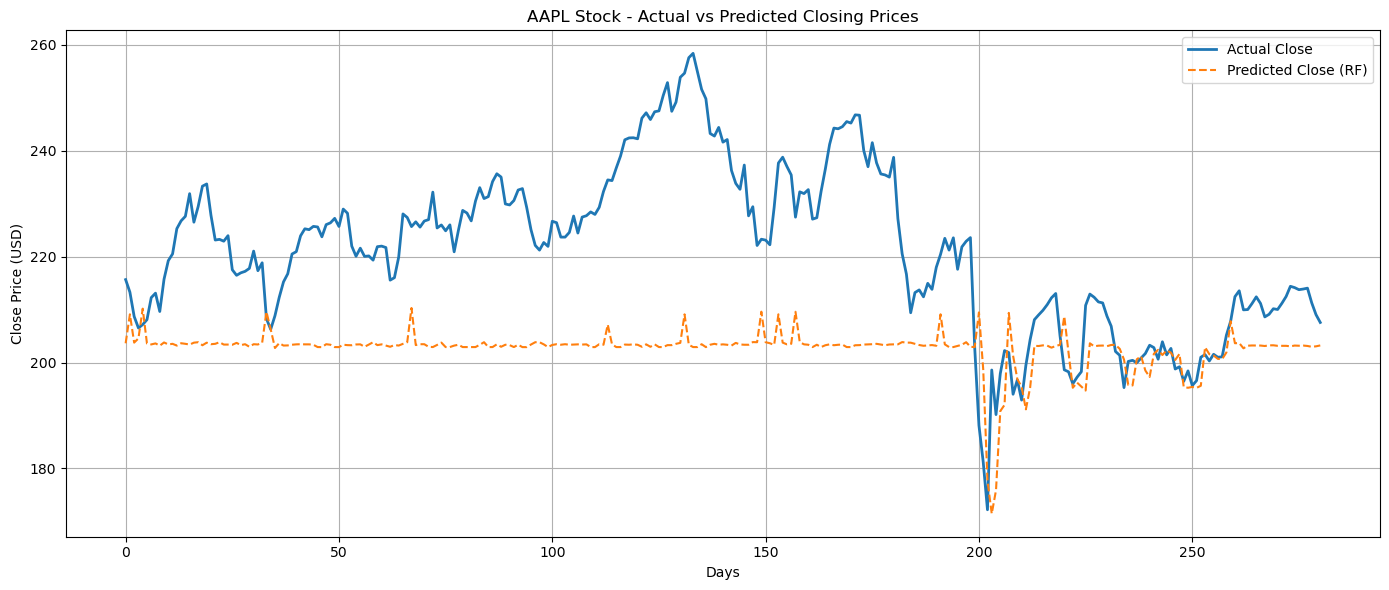

In [2]:
# 📌 Task 2: Predict Future Stock Prices (Short-Term)

# 📦 Import Libraries
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# 🎯 Load Data
stock_symbol = 'AAPL'  # Apple stock
data = yf.download(stock_symbol, start='2020-01-01', end='2025-08-01')
data = data[['Open', 'High', 'Low', 'Volume', 'Close']].dropna()

# 🎯 Prepare Features and Target
X = data[['Open', 'High', 'Low', 'Volume']]
y = data['Close'].shift(-1)  # Predict next day's Close

X = X[:-1]
y = y[:-1]

# 📊 Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle=False, test_size=0.2)

# 🔁 Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

# 🌲 Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

# 📈 Evaluation Metrics
print("🔍 Linear Regression:")
print("MSE:", mean_squared_error(y_test, lr_preds))
print("R2 Score:", r2_score(y_test, lr_preds))

print("\n🌲 Random Forest Regressor:")
print("MSE:", mean_squared_error(y_test, rf_preds))
print("R2 Score:", r2_score(y_test, rf_preds))

# 📉 Plot Actual vs Predicted (Random Forest)
plt.figure(figsize=(14, 6))
plt.plot(y_test.values, label='Actual Close', linewidth=2)
plt.plot(rf_preds, label='Predicted Close (RF)', linestyle='--')
plt.title(f'{stock_symbol} Stock - Actual vs Predicted Closing Prices')
plt.xlabel('Days')
plt.ylabel('Close Price (USD)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
